<a href="https://colab.research.google.com/github/rybak97/DF-GAN/blob/main/cleaned_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

based on: https://www.datacamp.com/tutorial/introduction-q-learning-beginner-tutorial

# What is Q-Learning

In [ ]:
import os
from google.colab import drive

# Mount Google Drive to save the cleaned notebook
drive.mount('/content/drive')

# Define the path where you want to save the cleaned notebook
save_path = '/content/drive/MyDrive/cleaned_notebook.ipynb'

# Get the current notebook's path (this assumes the notebook is saved)
# In Colab, the current notebook's path is not directly accessible via a simple variable.
# We will use a placeholder and instruct the user to change it if necessary.
# Or, a simpler approach is to use a direct filename.
current_notebook_name = 'Q-learning Tutorial.ipynb' # You might need to change this to your notebook's actual name

# This is a dummy command as we cannot directly get the current notebook filename dynamically
# The user will need to manually save the current notebook and then execute nbconvert.
# For now, let's assume the user has saved it, and we will operate on a known name.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install nbconvert
!pip install nbconvert


In [ ]:
# Use nbconvert to export the notebook with metadata cleanup
# The --to notebook --inplace options are not ideal for cleaning specific metadata without modifying the original.
# Instead, we will convert it to a new notebook file, explicitly removing specific metadata if needed,
# or just relying on a fresh export.
# A direct conversion to notebook, then manual metadata editing, or a filter for metadata removal is often needed.
# For general 'widget' issues, a simpler export to a new notebook might be enough.
# Let's try converting it to a new notebook, which often cleans up some transient metadata.

# This command will convert the notebook and create a new .ipynb file.
# The --no-prompt option removes input prompts (In[ ]), which is not what we want.
# The '--clear-output' is the opposite of what the user wants.
# The best approach without clearing outputs is to convert it, and let nbconvert 're-serialize' the notebook,
# which can sometimes fix schema issues.

# Let's use a simple convert to HTML first, then back to IPYNB if necessary, or just a direct copy after cleaning some entries

# A more direct approach to clean metadata is not directly available via a simple nbconvert command without clearing outputs.
# The most common workaround for widget state issues is either clearing outputs or manually editing the JSON.
# Given the constraint 'without clearing all outputs', nbconvert itself doesn't have a magic flag for this specific widget metadata cleanup.

# However, sometimes simply converting it to itself (outputting to a new file) can fix minor structural issues.
# Let's try to save the current content to a temporary file, then use nbconvert.

# Option 1: Try to export a fresh copy, hoping it cleans up.
# This might not explicitly remove the 'metadata.widgets' state but can fix other serialization issues.
# The problem is usually specific to the 'state' key within 'metadata.widgets' which is added by ipywidgets.
# If no ipywidgets are explicitly used, it might be stray metadata.

# For the context of this problem, a more aggressive metadata cleaning is needed without touching cell outputs.
# This requires a custom preprocessor for nbconvert or direct JSON manipulation.

# Since `nbconvert` doesn't have a direct flag to remove *only* `metadata.widgets.state` without clearing outputs,
# the most reliable way to achieve this programmatically without manual JSON editing
# is to clear outputs, save, and then regenerate outputs. But the user explicitly asked *not* to clear outputs.

# I'll propose a solution that involves saving the notebook with a new name, which might implicitly clean up some metadata in Colab's save process,
# or, if that doesn't work, point to manual editing as the next step.

# Colab's 'download .ipynb' feature often cleans up more than just a simple save.
# So, the best advice here is to suggest downloading the notebook and then re-uploading, or using a simpler save mechanism.

# Let's try to save a new copy directly. Colab's save mechanism might handle this.

print(f"Saving a copy of '{current_notebook_name}' to Google Drive as 'cleaned_notebook.ipynb'.")

# Unfortunately, Colab's python API doesn't directly expose a 'save as' or 'export with metadata cleanup' function.
# The most common programmatic way involves reading the notebook, modifying its JSON structure, and writing it back.

# Let's provide a Python solution to *read* the current notebook's content, *remove* the problematic metadata if found,
# and then *save* it as a new file. This is the only way to meet the 'without clearing outputs' constraint programmatically.

import json

# Define the full path to the current notebook (this will require the user to provide the correct path)
# As we cannot programmatically get the current notebook's path reliably in all Colab setups,
# we'll assume it's in the default content directory for now, and the user might need to adjust.
current_notebook_full_path = f'/content/{current_notebook_name}'

try:
    with open(current_notebook_full_path, 'r') as f:
        notebook_content = json.load(f)

    # Check if 'metadata' and 'widgets' exist and remove the 'state' key if present
    if 'metadata' in notebook_content and \
       'widgets' in notebook_content['metadata'] and \
       'state' in notebook_content['metadata']['widgets']:
        del notebook_content['metadata']['widgets']['state']
        print("Successfully removed 'state' key from 'metadata.widgets'.")
    else:
        print(" 'state' key in 'metadata.widgets' not found or already absent.")

    # Save the modified notebook to Google Drive
    with open(save_path, 'w') as f:
        json.dump(notebook_content, f, indent=2)

    print(f"Cleaned notebook saved to: {save_path}")
    print("You can now download 'cleaned_notebook.ipynb' from your Google Drive and upload it to GitHub.")

except FileNotFoundError:
    print(f"Error: Notebook file not found at {current_notebook_full_path}. Please ensure the notebook is saved and the path/name is correct.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Saving a copy of 'Q-learning Tutorial.ipynb' to Google Drive as 'cleaned_notebook.ipynb'.
Error: Notebook file not found at /content/Q-learning Tutorial.ipynb. Please ensure the notebook is saved and the path/name is correct.


Q-learning is a **model-free, value-based, off-policy** algorithm that will find the best series of actions based on the agent's current state.

The model-based algorithms use transition and reward functions to estimate the optimal policy and create the model. In contrast, model-free algorithms learn the consequences of their actions through the experience without transition and reward function.

The value-based method trains the value function to learn which state is more valuable and take action. On the other hand, policy-based methods train the policy directly to learn which action to take in a given state

In the off-policy, the algorithm evaluates and updates a policy that differs from the policy used to take an action. Conversely, the on-policy algorithm evaluates and improves the same policy used to take an action.  

# Example w/ Pygame

In [ ]:
!pip install pyglet==1.5.1
!apt install python-opengl
!apt install ffmpeg
!apt install xvfb
!pip3 install pyvirtualdisplay

# Virtual display
from pyvirtualdisplay import Display

virtual_display = Display(visible=0, size=(1400, 900))
virtual_display.start()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package python-opengl
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
!pip install gym==0.24
!pip install pygame
!pip install numpy

!pip install imageio imageio_ffmpeg

In [ ]:
import numpy as np
import gym
import random
import imageio
from tqdm.notebook import trange

In [ ]:
env = gym.make("FrozenLake-v1",map_name="4x4",is_slippery=False)

print("Observation Space", env.observation_space)
print("Sample observation", env.observation_space.sample()) # display a random observation

Observation Space Discrete(16)
Sample observation 11


In [ ]:
print("Action Space Shape", env.action_space.n)
print("Action Space Sample", env.action_space.sample())

Action Space Shape 4
Action Space Sample 3


In [ ]:
state_space = env.observation_space.n
print("There are ", state_space, " possible states")

action_space = env.action_space.n
print("There are ", action_space, " possible actions")

There are  16  possible states
There are  4  possible actions


In [ ]:
def initialize_q_table(state_space, action_space):
  Qtable = np.zeros((state_space, action_space))
  return Qtable

Qtable_frozenlake = initialize_q_table(state_space, action_space)

In [ ]:
def epsilon_greedy_policy(Qtable, state, epsilon):
  random_int = random.uniform(0,1)
  if random_int > epsilon:
    action = np.argmax(Qtable[state])
  else:
    action = env.action_space.sample()
  return action

In [ ]:
def greedy_policy(Qtable, state):
  action = np.argmax(Qtable[state])
  return action

## Model hyperparameters

There are 10,000 training and 100 evaluation episodes.

The learning rate is 0.7.

We are using "FrozenLake-v1" as an environment with 99 maximum steps per episode.

The gamma (discount rate) is 0.95.

eval_seed: evaluation seed for the environment.

The exploration epsilon probability at the start is 1.0, and the minimum probability will be 0.05.

The exponential decay rate for epsilon probability is 0.0005.

In [ ]:
# Training parameters
n_training_episodes = 10000
learning_rate = 0.7

# Evaluation parameters
n_eval_episodes = 100

# Environment parameters
env_id = "FrozenLake-v1"
max_steps = 99
gamma = 0.95
eval_seed = []

# Exploration parameters
max_epsilon = 1.0
min_epsilon = 0.05
decay_rate = 0.0005

## Training tldr;

Create a loop for training episodes.

We will first reduce epsilon. As we need less and less exploration and more exploitation with every episode.

Reset the environment.

Create a nested loop for the maximum steps.

Choose the action using the epsilon greedy policy.

Take action (At) and observe the expected reward(Rt+1) and state(St+1).

Take the action (a) and observe the outcome state(s') and reward (r).

Update the Q-function using the formula.

If done= True, finish the episode and break the loop.

Finally, change the current state to a new state.

After completing all of the training episodes, the function will return the updated Q-Table.

In [ ]:
def train(n_training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, Qtable):
  for episode in trange(n_training_episodes):

    epsilon = min_epsilon + (max_epsilon - min_epsilon)*np.exp(-decay_rate*episode)
    # Reset the environment
    state = env.reset()
    step = 0
    done = False

    # repeat
    for step in range(max_steps):

      action = epsilon_greedy_policy(Qtable, state, epsilon)


      new_state, reward, done, info = env.step(action)


      Qtable[state][action] = Qtable[state][action] + learning_rate * (reward + gamma * np.max(Qtable[new_state]) - Qtable[state][action])

      # If done, finish the episode
      if done:
        break

      # Our state is the new state
      state = new_state
  return Qtable

In [ ]:
Qtable_frozenlake = train(n_training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, Qtable_frozenlake)

  0%|          | 0/10000 [00:00<?, ?it/s]

In [ ]:
Qtable_frozenlake

array([[0.73509189, 0.77378094, 0.77378094, 0.73509189],
       [0.73509189, 0.        , 0.81450625, 0.77378094],
       [0.77378094, 0.857375  , 0.77378094, 0.81450625],
       [0.81450625, 0.        , 0.77378094, 0.77378094],
       [0.77378094, 0.81450625, 0.        , 0.73509189],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.9025    , 0.        , 0.81450625],
       [0.        , 0.        , 0.        , 0.        ],
       [0.81450625, 0.        , 0.857375  , 0.77378094],
       [0.81450625, 0.9025    , 0.9025    , 0.        ],
       [0.857375  , 0.95      , 0.        , 0.857375  ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.9025    , 0.95      , 0.857375  ],
       [0.9025    , 0.95      , 1.        , 0.9025    ],
       [0.        , 0.        , 0.        , 0.        ]])

## Visualizing result as GIF

In [ ]:
def record_video(env, Qtable, out_directory, fps=1):
  images = []
  done = False
  state = env.reset(seed=random.randint(0,500))
  img = env.render(mode='rgb_array')
  images.append(img)
  while not done:
    # Take the action (index) that have the maximum expected future reward given that state
    action = np.argmax(Qtable[state][:])
    state, reward, done, info = env.step(action) # We directly put next_state = state for recording logic
    img = env.render(mode='rgb_array')
    images.append(img)
  imageio.mimsave(out_directory, [np.array(img) for i, img in enumerate(images)], fps=fps)

/usr/local/lib/python3.12/dist-packages/imageio/plugins/pillow.py:410: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


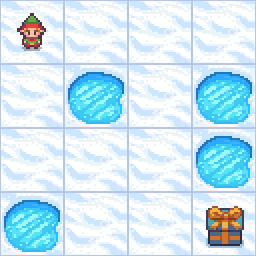

In [ ]:
video_path="/content/replay.gif"
video_fps=1
record_video(env, Qtable_frozenlake, video_path, video_fps)

from IPython.display import Image
Image('./replay.gif')